In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [3]:
df=pd.read_csv("C:/Users/Dhruv/Onedrive/Desktop/samsung/aqi/delhi_ncr_aqi_dataset.csv")
df

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
201660,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
201661,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe
201662,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Ghaziabad,...,170.7,20.9,6.98,22.9,15.4,51,6.8,1.2,500,Severe


In [4]:
df['station'].unique()

array(['Anand Vihar, Delhi', 'Jahangirpuri, Delhi', 'Wazirpur, Delhi',
       'Bawana, Delhi', 'ITO, Delhi', 'Punjabi Bagh, Delhi',
       'Okhla Phase 2, Delhi', 'Shadipur, Delhi', 'Rohini, Delhi',
       'RK Puram, Delhi', 'Siri Fort, Delhi', 'Dwarka Sec 8, Delhi',
       'NSIT Dwarka, Delhi', 'Mandir Marg, Delhi', 'Noida Sec 62',
       'Noida Sec 125', 'Greater Noida', 'Gurugram Vikas Sadan',
       'Gurugram Sec 51', 'Faridabad Sec 16A', 'Faridabad New Town',
       'Ghaziabad Vasundhara', 'Ghaziabad Loni'], dtype=object)

In [5]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [6]:
df = df.sort_values('datetime').reset_index(drop=True)
df2=df.copy()

In [7]:
df1=df[df['station'] == 'NSIT Dwarka, Delhi']
df1=df1.drop(columns=['station'])
df1

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
2,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,111.2,22.6,5.13,15.2,9.9,100,2.2,1.3,500,Severe
25,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,95.0,18.3,3.92,25.1,17.2,46,9.9,2.6,408,Severe
67,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,128.4,25.2,5.75,25.6,14.1,64,6.6,2.5,466,Severe
70,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,104.1,27.3,4.49,17.5,12.5,45,4.4,0.7,500,Severe
98,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,Thursday,0,winter,Delhi,...,125.5,20.4,4.44,15.3,6.3,100,2.4,0.8,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025-12-30 23:00:00,2025-12-30,2025,12,30,23,Tuesday,0,winter,Delhi,...,107.4,25.9,4.77,22.4,14.3,49,6.8,2.9,500,Severe
201578,2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Delhi,...,88.9,29.1,5.50,16.8,8.2,100,2.5,0.8,500,Severe
201597,2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Delhi,...,59.3,18.2,2.99,28.5,21.3,63,8.8,3.1,349,Very Poor
201627,2025-12-31 18:00:00,2025-12-31,2025,12,31,18,Wednesday,0,winter,Delhi,...,147.3,21.2,5.53,25.1,16.4,61,5.9,2.9,426,Severe


In [8]:
df1['aqi_lag_1']  = df1['aqi'].shift(1)   # 6 hours ago
df1['aqi_lag_2']  = df1['aqi'].shift(2)   # 12 hours ago
df1['aqi_lag_4']  = df1['aqi'].shift(4)   # 24 hours ago (daily cycle)
df1['aqi_lag_8']  = df1['aqi'].shift(8)   # 48 hours ago
df1['aqi_lag_28'] = df1['aqi'].shift(28)  # ~7 days

In [9]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [10]:
df1 = df1.dropna().reset_index(drop=True)


In [11]:
features = [
    'pm25','pm10','no2','so2','co','o3',
    'temperature','humidity','wind_speed','visibility',
    'year','month','day','hour','is_weekend',
    'season_winter','season_summer','season_post_monsoon',
    'aqi_lag_1','aqi_lag_2','aqi_lag_4','aqi_lag_8','aqi_lag_28'
]

In [12]:
from sklearn.preprocessing import StandardScaler

X = df1[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance per component:")
print(explained_variance)

print("Cumulative variance:")
print(explained_variance.cumsum())

Explained variance per component:
[4.81433138e-01 1.17919765e-01 7.93949041e-02 5.56004008e-02
 4.72733951e-02 4.37559156e-02 4.34145809e-02 4.29342888e-02
 2.32366981e-02 1.82613830e-02 1.09681502e-02 8.30062938e-03
 7.36977174e-03 4.34123295e-03 3.66274504e-03 2.57925755e-03
 2.26164612e-03 1.90926909e-03 1.41242240e-03 1.35653532e-03
 1.25660372e-03 1.09511952e-03 2.62147508e-04]
Cumulative variance:
[0.48143314 0.5993529  0.67874781 0.73434821 0.7816216  0.82537752
 0.8687921  0.91172639 0.93496309 0.95322447 0.96419262 0.97249325
 0.97986302 0.98420425 0.987867   0.99044626 0.9927079  0.99461717
 0.99602959 0.99738613 0.99864273 0.99973785 1.        ]


In [14]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (8740, 23)
Reduced shape: (8740, 10)


In [15]:
import pandas as pd

# Create a DataFrame for easier reading
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Explained Variance': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})

print(variance_df)

     PC  Explained Variance  Cumulative Variance
0   PC1            0.481433             0.481433
1   PC2            0.117920             0.599353
2   PC3            0.079395             0.678748
3   PC4            0.055600             0.734348
4   PC5            0.047273             0.781622
5   PC6            0.043756             0.825378
6   PC7            0.043415             0.868792
7   PC8            0.042934             0.911726
8   PC9            0.023237             0.934963
9  PC10            0.018261             0.953224


In [16]:
X_pca

array([[ 4.63225332,  0.88326829, -2.53390285, ..., -1.77916626,
        -0.73456218, -0.95731598],
       [ 2.77042196, -0.82939728, -2.09200161, ..., -1.90402037,
         0.18773421, -0.88889   ],
       [ 3.37763747, -0.44902209, -1.96161944, ..., -1.90657862,
        -0.13466084, -0.84520953],
       ...,
       [ 2.72320503,  0.23541493, -0.61815402, ...,  1.76188784,
         1.98818228,  0.80219306],
       [ 3.58639529,  0.41524283, -0.09411098, ...,  1.78251529,
         1.10546481,  0.96998074],
       [ 3.45286597, -0.09644446, -0.08241387, ...,  1.70074705,
         1.4329109 ,  1.05239131]], shape=(8740, 10))

In [25]:
explained = pca.explained_variance_ratio_
print("Explained variance:", explained)
print("Cumulative variance:", explained.cumsum())

Explained variance: [0.48143314 0.11791977 0.0793949  0.0556004  0.0472734  0.04375592
 0.04341458 0.04293429 0.0232367  0.01826138]
Cumulative variance: [0.48143314 0.5993529  0.67874781 0.73434821 0.7816216  0.82537752
 0.8687921  0.91172639 0.93496309 0.95322447]


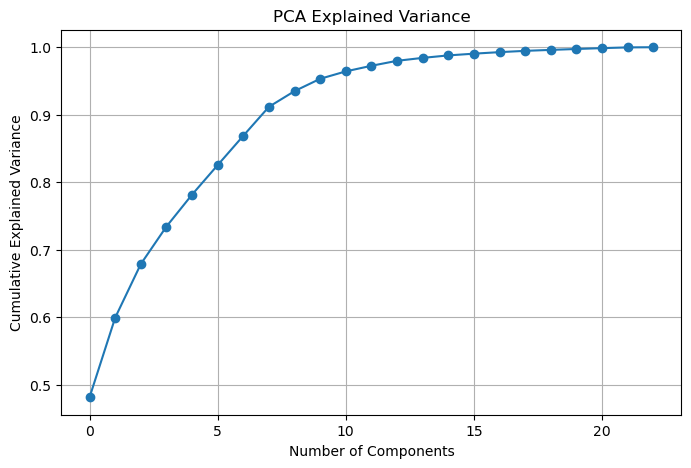

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

In [26]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=features
)

print(loadings["PC1"].sort_values(ascending=False))

aqi_lag_4              0.284262
aqi_lag_8              0.282930
aqi_lag_2              0.280520
aqi_lag_1              0.279198
aqi_lag_28             0.275763
pm25                   0.275641
pm10                   0.274049
co                     0.269164
no2                    0.268532
so2                    0.267401
season_winter          0.247407
month                  0.080401
season_post_monsoon    0.061131
day                    0.002980
hour                  -0.004153
year                  -0.004919
is_weekend            -0.009049
humidity              -0.012386
season_summer         -0.107001
o3                    -0.117982
wind_speed            -0.190650
temperature           -0.219341
visibility            -0.240396
Name: PC1, dtype: float64


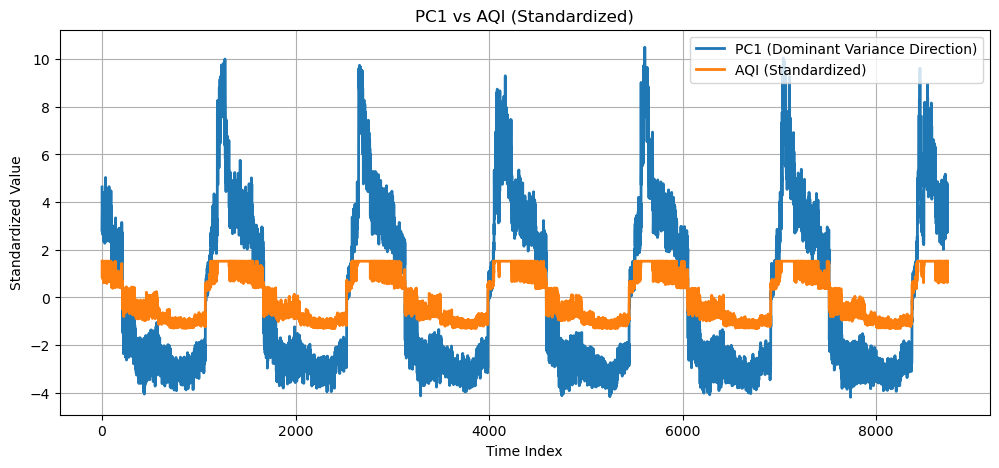

In [28]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

# PC1 from PCA
pc1 = X_pca[:, 0]

# Align AQI with PCA rows (important if you used dropna())
aqi_aligned = df1.loc[X.index, 'aqi'].values

# Standardize AQI for fair comparison
scaler = StandardScaler()
aqi_scaled = scaler.fit_transform(aqi_aligned.reshape(-1,1)).flatten()

# Plot
plt.figure(figsize=(12,5))

plt.plot(pc1, label="PC1 (Dominant Variance Direction)", linewidth=2)
plt.plot(aqi_scaled, label="AQI (Standardized)", linewidth=2)

plt.title("PC1 vs AQI (Standardized)")
plt.xlabel("Time Index")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
corr = np.corrcoef(pc1, aqi_scaled)[0,1]
print(corr)

0.951556843334235


In [36]:
df1=df1.drop(columns=['aqi_category'])

In [37]:
df1

,year,month,day,hour,is_weekend,pm25,pm10,no2,so2,co,...,visibility,aqi,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28,season_post_monsoon,season_summer,season_winter
0,2020,1,8,6,0,367.1,648.7,108.9,26.3,5.68,...,0.5,500,500.0,405.0,500.0,500.0,500.0,False,False,True
1,2020,1,8,12,0,221.7,428.5,76.4,13.4,3.29,...,2.5,398,500.0,500.0,351.0,460.0,408.0,False,False,True
2,2020,1,8,18,0,228.5,375.6,129.2,16.8,4.81,...,2.1,383,398.0,500.0,405.0,500.0,466.0,False,False,True
3,2020,1,8,23,0,292.3,637.7,94.5,26.8,4.07,...,2.2,500,383.0,398.0,500.0,490.0,500.0,False,False,True
4,2020,1,9,6,0,268.0,545.5,96.8,22.7,4.47,...,3.0,500,500.0,383.0,500.0,500.0,500.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,272.5,574.7,107.4,25.9,4.77,...,2.9,500,390.0,372.0,435.0,389.0,500.0,False,False,True
8736,2025,12,31,6,0,308.5,666.1,88.9,29.1,5.50,...,0.8,500,500.0,390.0,500.0,500.0,500.0,False,False,True
8737,2025,12,31,12,0,183.5,369.0,59.3,18.2,2.99,...,3.1,349,500.0,500.0,372.0,451.0,394.0,False,False,True
8738,2025,12,31,18,0,260.0,450.7,147.3,21.2,5.53,...,2.9,426,349.0,500.0,390.0,416.0,442.0,False,False,True


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# 1. Define your splits (as per your code)
train_df = df1[df1['year'] < 2025]
test_df  = df1[df1['year'] == 2025]

drop_cols = ['aqi']

X_train_raw = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']
X_test_raw = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']



# 2. Scaling (Critical for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 3. Apply PCA (Retaining 95% variance / 10 components)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled) # Transform test data using train's PCA logic

print(f"Reduced feature count from {X_train_raw.shape[1]} to {X_train_pca.shape[1]}")



# 4. Train XGBoost Regressor on PCA components
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train_pca, y_train)

# 5. Evaluate
y_pred = xgb.predict(X_test_pca)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

r2_xgb = r2_score(y_test, y_pred)

print("R2:", r2_xgb)

Reduced feature count from 23 to 10
MAE: 13.19
RMSE: 18.26
R2: 0.9882751703262329


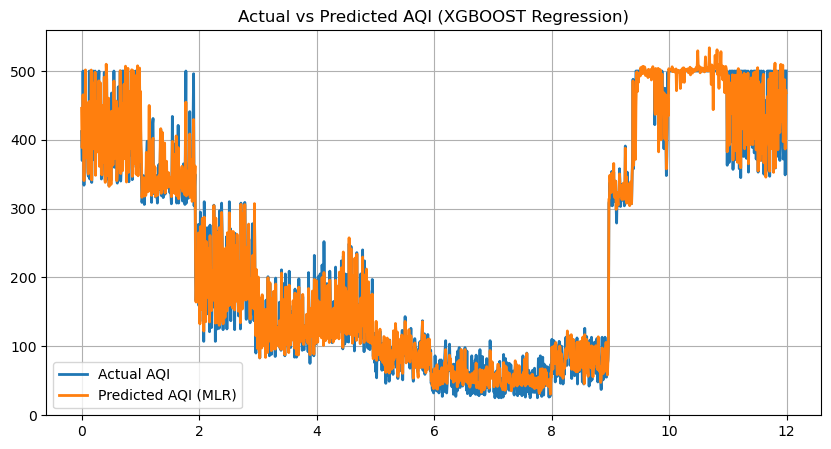

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred, label="Predicted AQI (MLR)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (XGBOOST Regression)")
plt.show()


In [34]:
df1 = pd.get_dummies(df1, columns=['season'], drop_first=True)


In [36]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
2,2020,1,1,6,0,500,False,False,True,NaN,NaN,NaN,NaN,NaN
25,2020,1,1,12,0,408,False,False,True,500.0,NaN,NaN,NaN,NaN
67,2020,1,1,18,0,466,False,False,True,408.0,500.0,NaN,NaN,NaN
70,2020,1,1,23,0,500,False,False,True,466.0,408.0,NaN,NaN,NaN
98,2020,1,2,6,0,500,False,False,True,500.0,466.0,500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
201578,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
201597,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
201627,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [37]:
df.isna().sum()

year          0
month         0
day           0
hour          0
is_weekend    0
season        0
station       0
aqi           0
dtype: int64

In [38]:
df1 = df1.dropna().reset_index(drop=True)


In [39]:
df1

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,500,False,False,True,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,398,False,False,True,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,383,False,False,True,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,500,False,False,True,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,500,False,False,True,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [40]:
df1.columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'aqi',
       'season_post_monsoon', 'season_summer', 'season_winter', 'aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'],
      dtype='object')

In [41]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# sort by time
lstm_df = df1.sort_values(['year','month','day','hour']).reset_index(drop=True)

feature_cols = [
    'year', 'month', 'day',             
    'hour', 'is_weekend',
    'season_winter', 'season_summer', 'season_post_monsoon', 'aqi_lag_1',
       'aqi_lag_2', 'aqi_lag_4', 'aqi_lag_8', 'aqi_lag_28'
]

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------
train_df = lstm_df[lstm_df['year'] < 2025]
test_df  = lstm_df[lstm_df['year'] == 2025]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values

y_train = train_df['aqi'].values.reshape(-1,1)
y_test  = test_df['aqi'].values.reshape(-1,1)

# -----------------------------
# SCALING (fit ONLY on train)
# -----------------------------
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = X_scaler.fit_transform(X_train)
X_test  = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test  = y_scaler.transform(y_test)

# -----------------------------
# CREATE SEQUENCES
# -----------------------------
TIMESTEPS = 24  # 1 day window

def create_sequences(X, y, t):
    X_seq, y_seq = [], []
    for i in range(len(X) - t):
        X_seq.append(X[i:i+t])
        y_seq.append(y[i+t])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  TIMESTEPS)





In [42]:
lstm_df

,year,month,day,hour,is_weekend,aqi,season_post_monsoon,season_summer,season_winter,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,8,6,0,500,False,False,True,500.0,405.0,500.0,500.0,500.0
1,2020,1,8,12,0,398,False,False,True,500.0,500.0,351.0,460.0,408.0
2,2020,1,8,18,0,383,False,False,True,398.0,500.0,405.0,500.0,466.0
3,2020,1,8,23,0,500,False,False,True,383.0,398.0,500.0,490.0,500.0
4,2020,1,9,6,0,500,False,False,True,500.0,383.0,500.0,500.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8735,2025,12,30,23,0,500,False,False,True,390.0,372.0,435.0,389.0,500.0
8736,2025,12,31,6,0,500,False,False,True,500.0,390.0,500.0,500.0,500.0
8737,2025,12,31,12,0,349,False,False,True,500.0,500.0,372.0,451.0,394.0
8738,2025,12,31,18,0,426,False,False,True,349.0,500.0,390.0,416.0,442.0


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm = Sequential()
lstm.add(LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm.add(Dense(1))

lstm.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

lstm.summary()


C:\Users\Dhruv\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=15,        
    min_delta=0.0015,     
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=6,
    min_lr=1e-5,
    verbose=1
)

history = lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=120,         
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3230 - mae: 0.3230 - val_loss: 0.2485 - val_mae: 0.2485 - learning_rate: 0.0010
Epoch 2/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2217 - mae: 0.2217 - val_loss: 0.2693 - val_mae: 0.2693 - learning_rate: 0.0010
Epoch 3/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2233 - mae: 0.2233 - val_loss: 0.2097 - val_mae: 0.2097 - learning_rate: 0.0010
Epoch 4/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1941 - mae: 0.1941 - val_loss: 0.1798 - val_mae: 0.1798 - learning_rate: 0.0010
Epoch 5/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1700 - mae: 0.1700 - val_loss: 0.2164 - val_mae: 0.2164 - learning_rate: 0.0010
Epoch 6/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1820 - mae: 0.1820 - val_loss: 0.1746 - val_mae: 0.1746 - learning_rate: 0.0010
Epoch 7/120
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1845 - mae: 0.1845 - val_loss: 0.1685 - val_mae: 0.1685 - learning_rate:

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predict
y_pred_lstm = lstm.predict(X_test_seq)

# inverse scale FIRST (keep 2D shape)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm)
y_test_actual = y_scaler.inverse_transform(y_test_seq)

# flatten for metrics
y_pred_lstm = y_pred_lstm.flatten()
y_test_actual = y_test_actual.flatten()

# metrics on real AQI values
mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)
from sklearn.metrics import r2_score
r2= r2_score(y_test_actual, y_pred_lstm)
print("LSTM R2:", r2)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM MAE: 23.4590842637511
LSTM RMSE: 32.71341201607788
LSTM R2: 0.9623366133494412


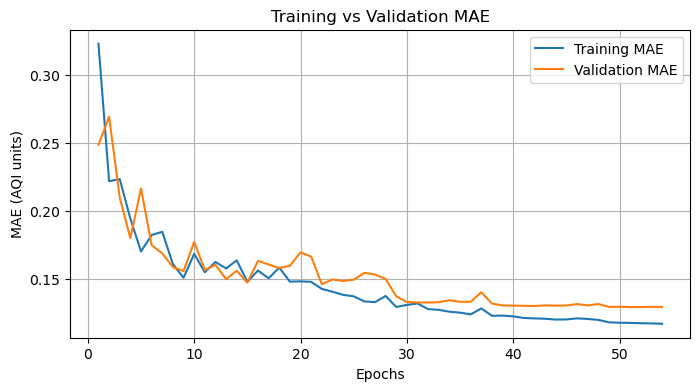

In [62]:
epochs = range(1, len(history.history['mae']) + 1)

plt.figure(figsize=(8, 4))

plt.plot(epochs, history.history['mae'], label='Training MAE')
plt.plot(epochs, history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epochs')
plt.ylabel('MAE (AQI units)')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)

plt.show()


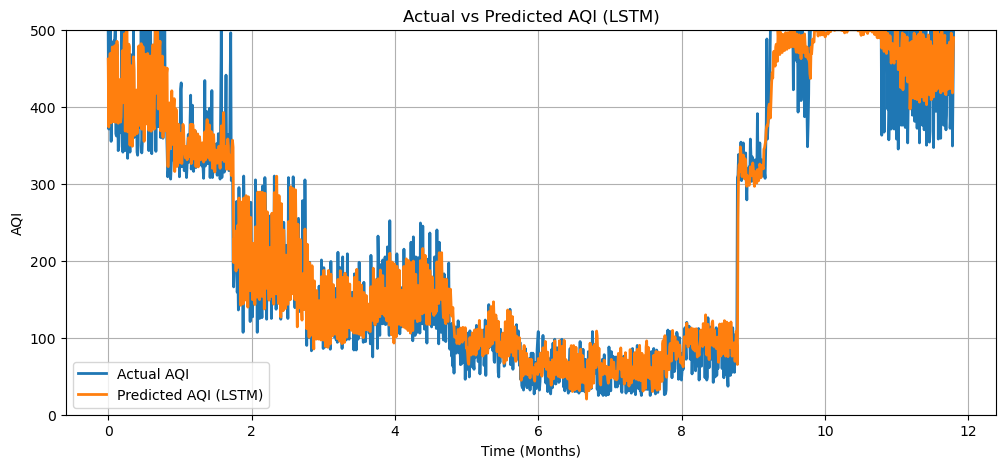

In [63]:
plt.figure(figsize=(12, 5))

# clip predictions to AQI range
y_pred_lstm = np.clip(y_pred_lstm, 0, 500)

# use correct length (same as plotted data)
n_samples = len(y_test_actual)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months, y_test_actual, label='Actual AQI', linewidth=2)
plt.plot(x_months, y_pred_lstm, label='Predicted AQI (LSTM)', linewidth=2)


# keep axis consistent with AQI definition
plt.ylim(0, 500)

plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI (LSTM)')
plt.legend()
plt.grid(True)

plt.savefig("lstm_actual_vs_predicted.jpg", dpi=300, bbox_inches="tight")
plt.show()


In [64]:
df3=df2[['year', 'month', 'day', 'hour',
       'is_weekend','season', 'station', 'aqi']]

In [65]:
df3=df3.copy()

In [66]:
df3['aqi_lag_1']  = df3['aqi'].shift(1)   # 6 hours ago
df3['aqi_lag_2']  = df3['aqi'].shift(2)   # 12 hours ago
df3['aqi_lag_4']  = df3['aqi'].shift(4)   # 24 hours ago (daily cycle)
df3['aqi_lag_8']  = df3['aqi'].shift(8)   # 48 hours ago
df3['aqi_lag_28'] = df3['aqi'].shift(28)  # ~7 days

In [67]:
df3

,year,month,day,hour,is_weekend,season,station,aqi,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
0,2020,1,1,6,0,winter,"Anand Vihar, Delhi",500,NaN,NaN,NaN,NaN,NaN
1,2020,1,1,6,0,winter,"Mandir Marg, Delhi",399,500.0,NaN,NaN,NaN,NaN
2,2020,1,1,6,0,winter,"NSIT Dwarka, Delhi",500,399.0,500.0,NaN,NaN,NaN
3,2020,1,1,6,0,winter,Noida Sec 125,500,500.0,399.0,NaN,NaN,NaN
4,2020,1,1,6,0,winter,"Dwarka Sec 8, Delhi",473,500.0,500.0,500.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201659,2025,12,31,23,0,winter,Noida Sec 62,500,500.0,500.0,390.0,500.0,422.0
201660,2025,12,31,23,0,winter,Noida Sec 125,489,500.0,500.0,500.0,405.0,500.0
201661,2025,12,31,23,0,winter,Greater Noida,500,489.0,500.0,500.0,492.0,397.0
201662,2025,12,31,23,0,winter,"Wazirpur, Delhi",500,500.0,489.0,500.0,500.0,436.0


In [68]:
df3=df3[df3['station'] == 'NSIT Dwarka, Delhi']
df3=df3.drop(columns=['station'])
df3

,year,month,day,hour,is_weekend,season,aqi,aqi_lag_1,aqi_lag_2,aqi_lag_4,aqi_lag_8,aqi_lag_28
2,2020,1,1,6,0,winter,500,399.0,500.0,NaN,NaN,NaN
25,2020,1,1,12,0,winter,408,448.0,414.0,500.0,500.0,NaN
67,2020,1,1,18,0,winter,466,500.0,500.0,500.0,500.0,500.0
70,2020,1,1,23,0,winter,500,500.0,456.0,500.0,500.0,500.0
98,2020,1,2,6,0,winter,500,483.0,500.0,500.0,444.0,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...
201565,2025,12,30,23,0,winter,500,500.0,500.0,500.0,500.0,440.0
201578,2025,12,31,6,0,winter,500,500.0,500.0,500.0,500.0,500.0
201597,2025,12,31,12,0,winter,349,416.0,452.0,500.0,500.0,500.0
201627,2025,12,31,18,0,winter,426,415.0,476.0,500.0,500.0,374.0


In [69]:
df3 = pd.get_dummies(df3, columns=['season'], drop_first=True)


In [70]:
df3=df3.apply(pd.to_numeric)
df3.dtypes

year                     int64
month                    int64
day                      int64
hour                     int64
is_weekend               int64
aqi                      int64
aqi_lag_1              float64
aqi_lag_2              float64
aqi_lag_4              float64
aqi_lag_8              float64
aqi_lag_28             float64
season_post_monsoon       bool
season_summer             bool
season_winter             bool
dtype: object

In [71]:
train_df = df3[df3['year'] < 2025]
test_df  = df3[df3['year'] == 2025]

drop_cols = ['aqi']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['aqi']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['aqi']


In [72]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)


XGBoost MAE: 21.939495086669922
XGBoost RMSE: 29.076291460529422


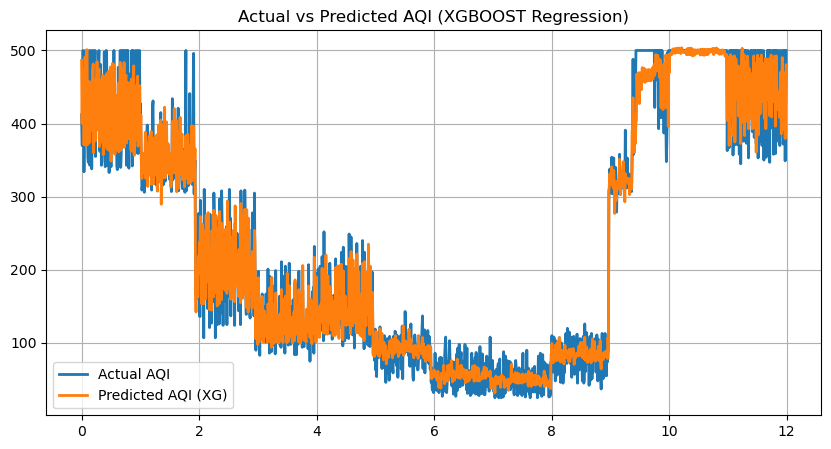

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
# Number of samples
n_samples = len(y_test)

# Convert samples to months (1 month = 120 samples)
x_months = np.arange(n_samples) / 121.66

plt.plot(x_months,y_test.values, label="Actual AQI", linewidth=2)
plt.plot(x_months,y_pred_xgb, label="Predicted AQI (XG)", linewidth=2)
plt.grid(True)
plt.legend()
plt.title("Actual vs Predicted AQI (XGBOOST Regression)")

plt.show()


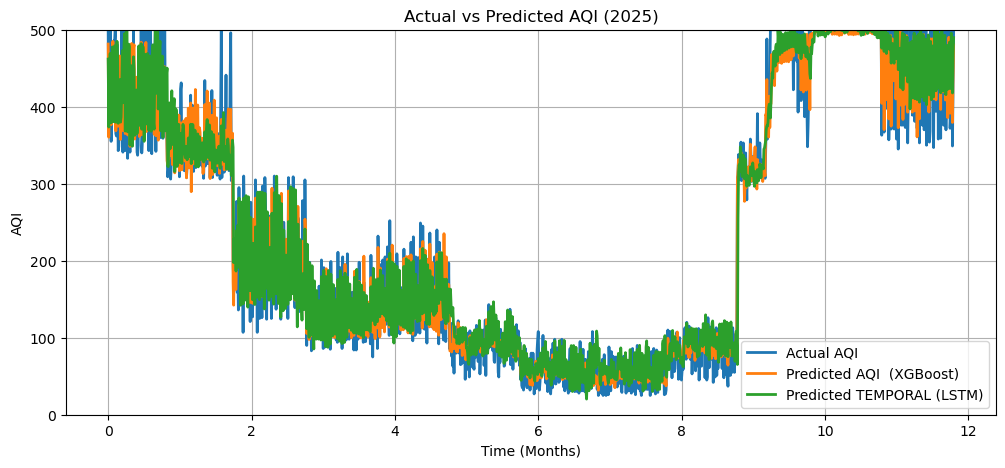

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Convert everything to numpy arrays
y_actual = np.array(y_test_actual)

y_xgb    = np.array(y_pred_xgb)
y_lstm   = np.array(y_pred_lstm)

# Find minimum length
min_len = min(len(y_actual), len(y_lstm), len(y_xgb))

# Align from the END (important for time series)
y_actual = y_actual[-min_len:]
y_lstm   = y_lstm[-min_len:]
y_xgb    = y_xgb[-min_len:]

# X-axis
x_months = np.arange(min_len) / 121.66

plt.figure(figsize=(12, 5))

plt.plot(x_months, y_actual, label='Actual AQI', linewidth=2)

plt.plot(x_months, y_xgb, label='Predicted AQI  (XGBoost)', linewidth=2)

plt.plot(x_months, y_lstm, label='Predicted TEMPORAL (LSTM)', linewidth=2)

plt.ylim(0, 500)
plt.xlabel('Time (Months)')
plt.ylabel('AQI')
plt.title('Actual vs Predicted AQI (2025)')
plt.legend()
plt.grid(True)
plt.savefig("LSTM vs XG BOOST.jpg", dpi=300, bbox_inches="tight")

plt.show()


In [60]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [76]:
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
from sklearn.metrics import r2_score

r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost R2:", r2_xgb)



XGBoost MAE: 21.939495086669922
XGBoost RMSE: 29.076291460529422
XGBoost R2: 0.9702720046043396
